In [12]:
import numpy as np
import mne

In [13]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file /Users/siddarthchilukuri/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [14]:
print(raw)
print(raw.info)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>
<Info | 14 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).


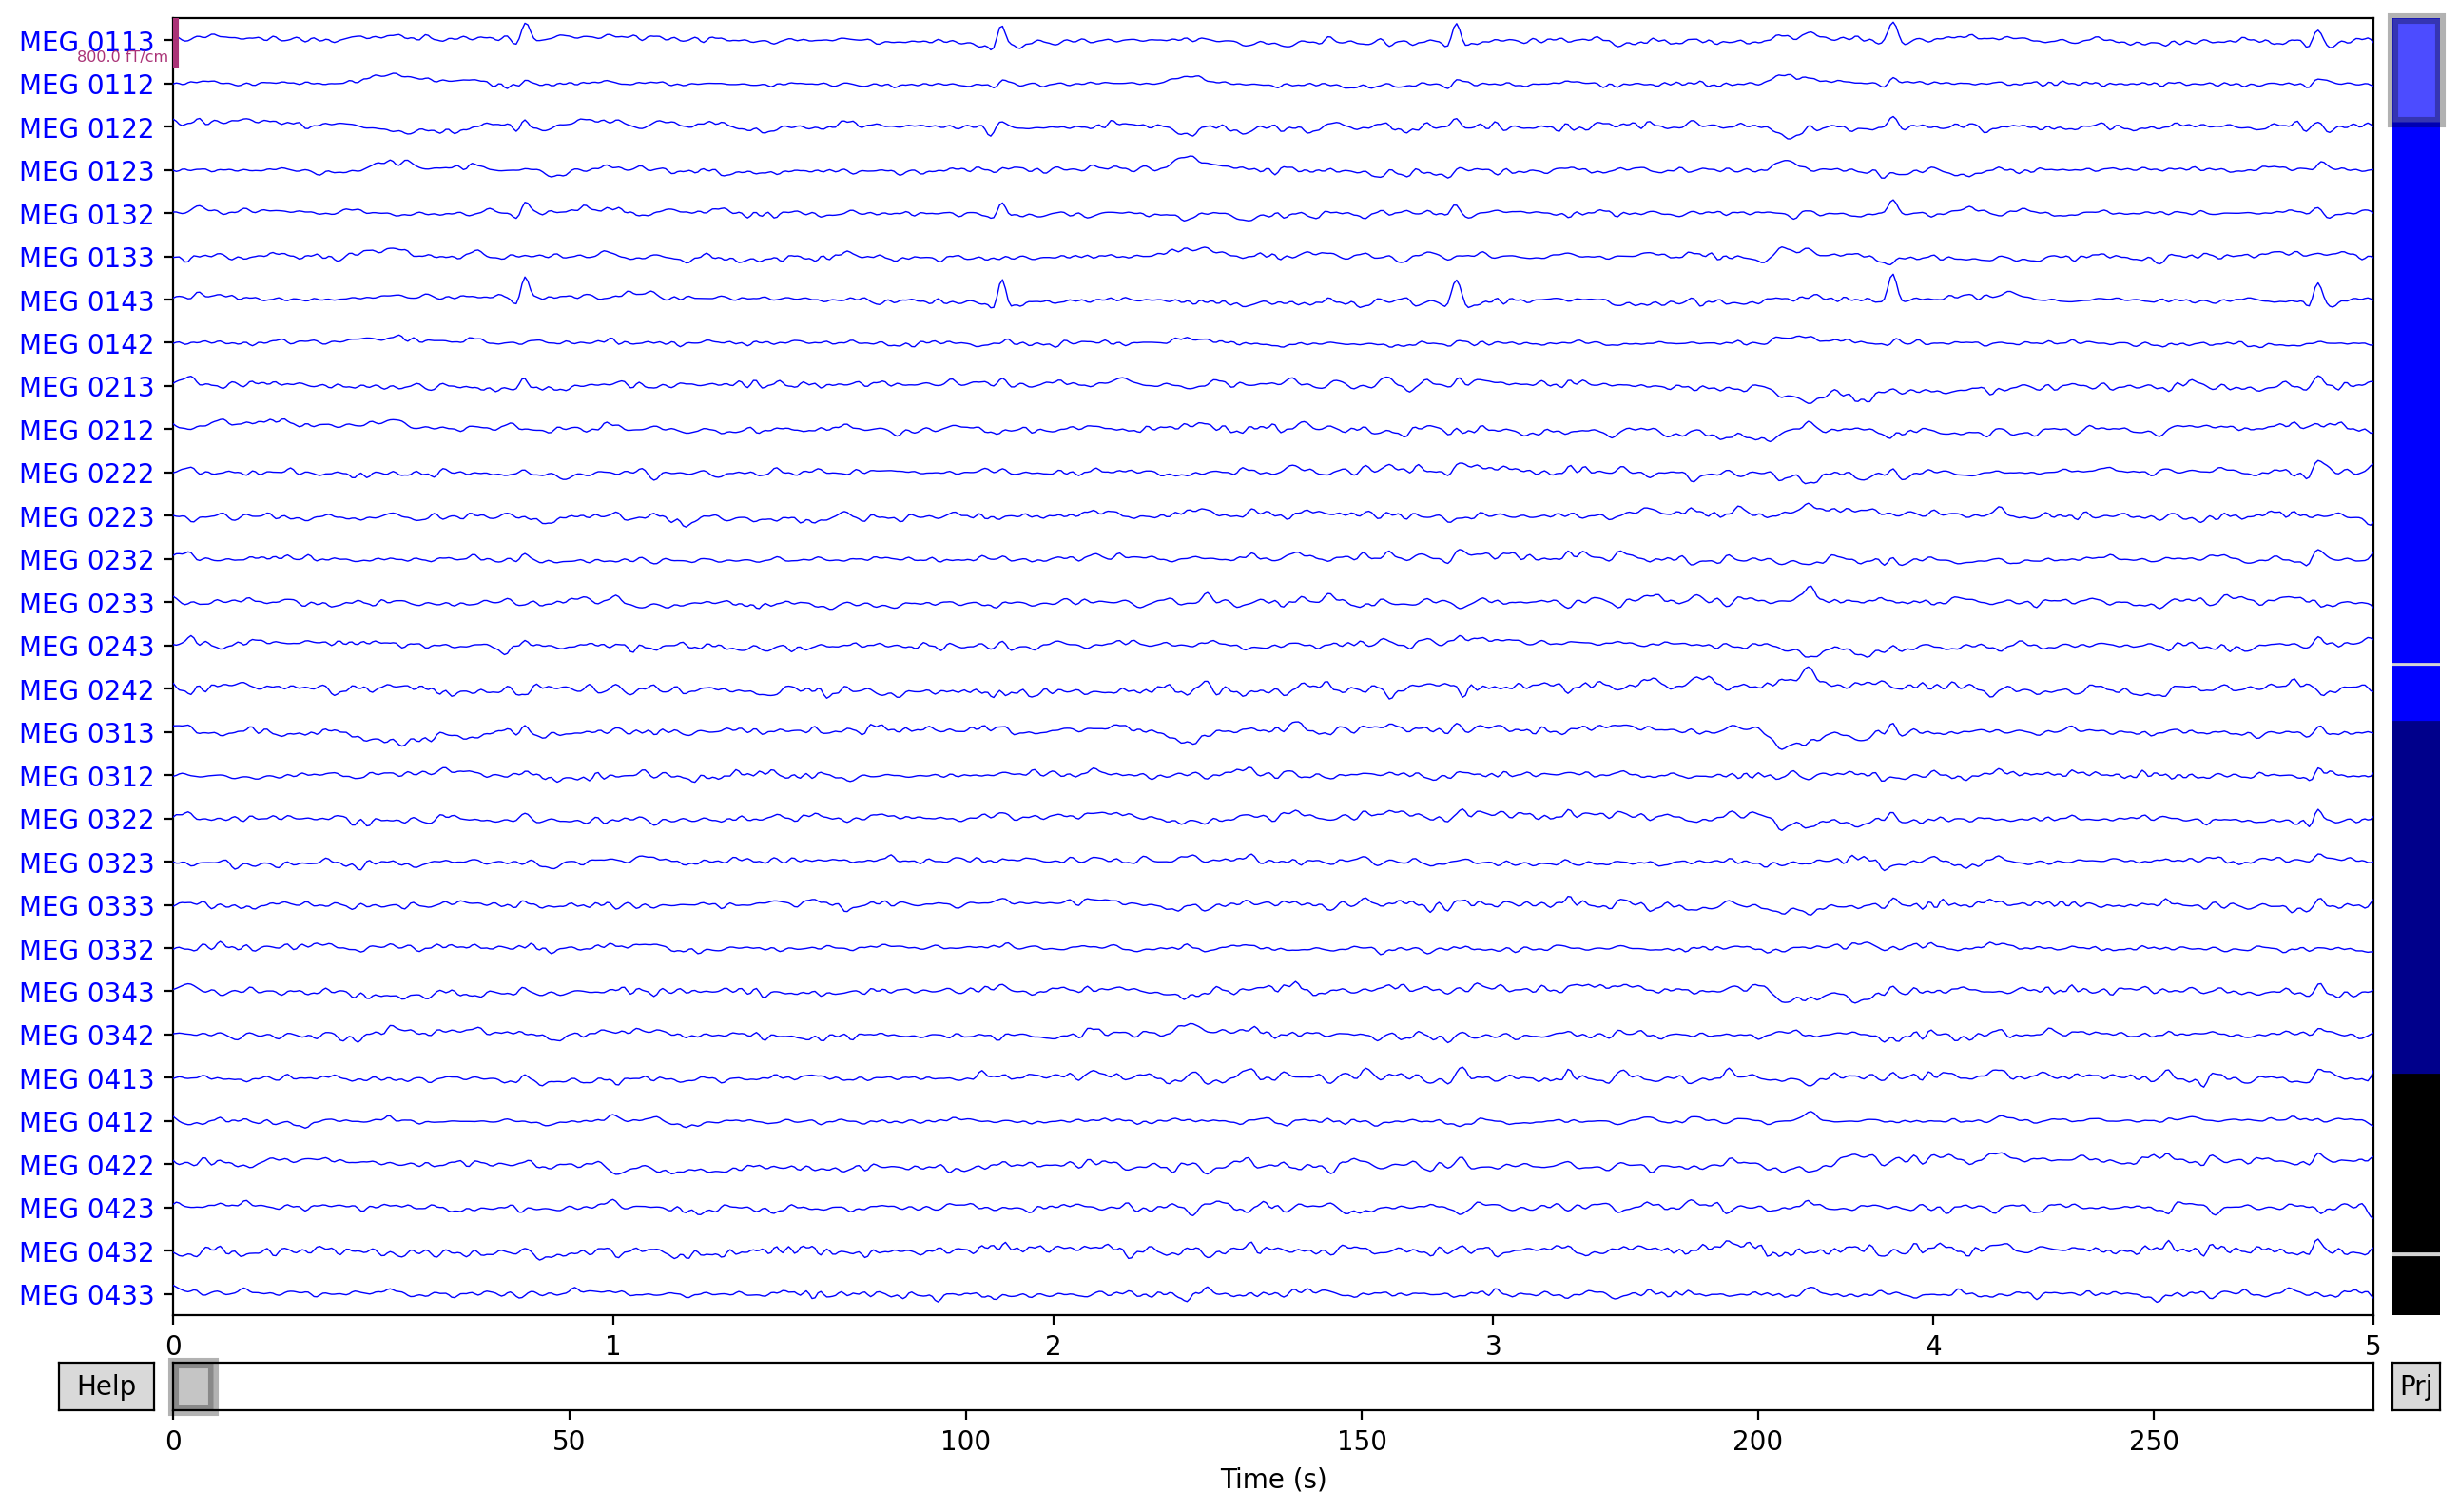

Channels marked as bad:
['EEG 053', np.str_('MEG 2443')]


In [16]:
%matplotlib qt

raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

In [15]:
%matplotlib qt

ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = []
ica.plot_properties(raw)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 6.5s.
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 1400x1200 with 6 Axes>,
 <Figure size 1400x1200 with 6 Axes>,
 <Figure size 1400x1200 with 6 Axes>,
 <Figure size 1400x1200 with 6 Axes>,
 <Figure size 1400x1200 with 6 Axes>]

2025-05-08 13:13:08.074 Python[66155:1401700] +[IMKClient subclass]: chose IMKClient_Modern
2025-05-08 13:13:08.074 Python[66155:1401700] +[IMKInputSession subclass]: chose IMKInputSession_Modern


Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 364 PCA components


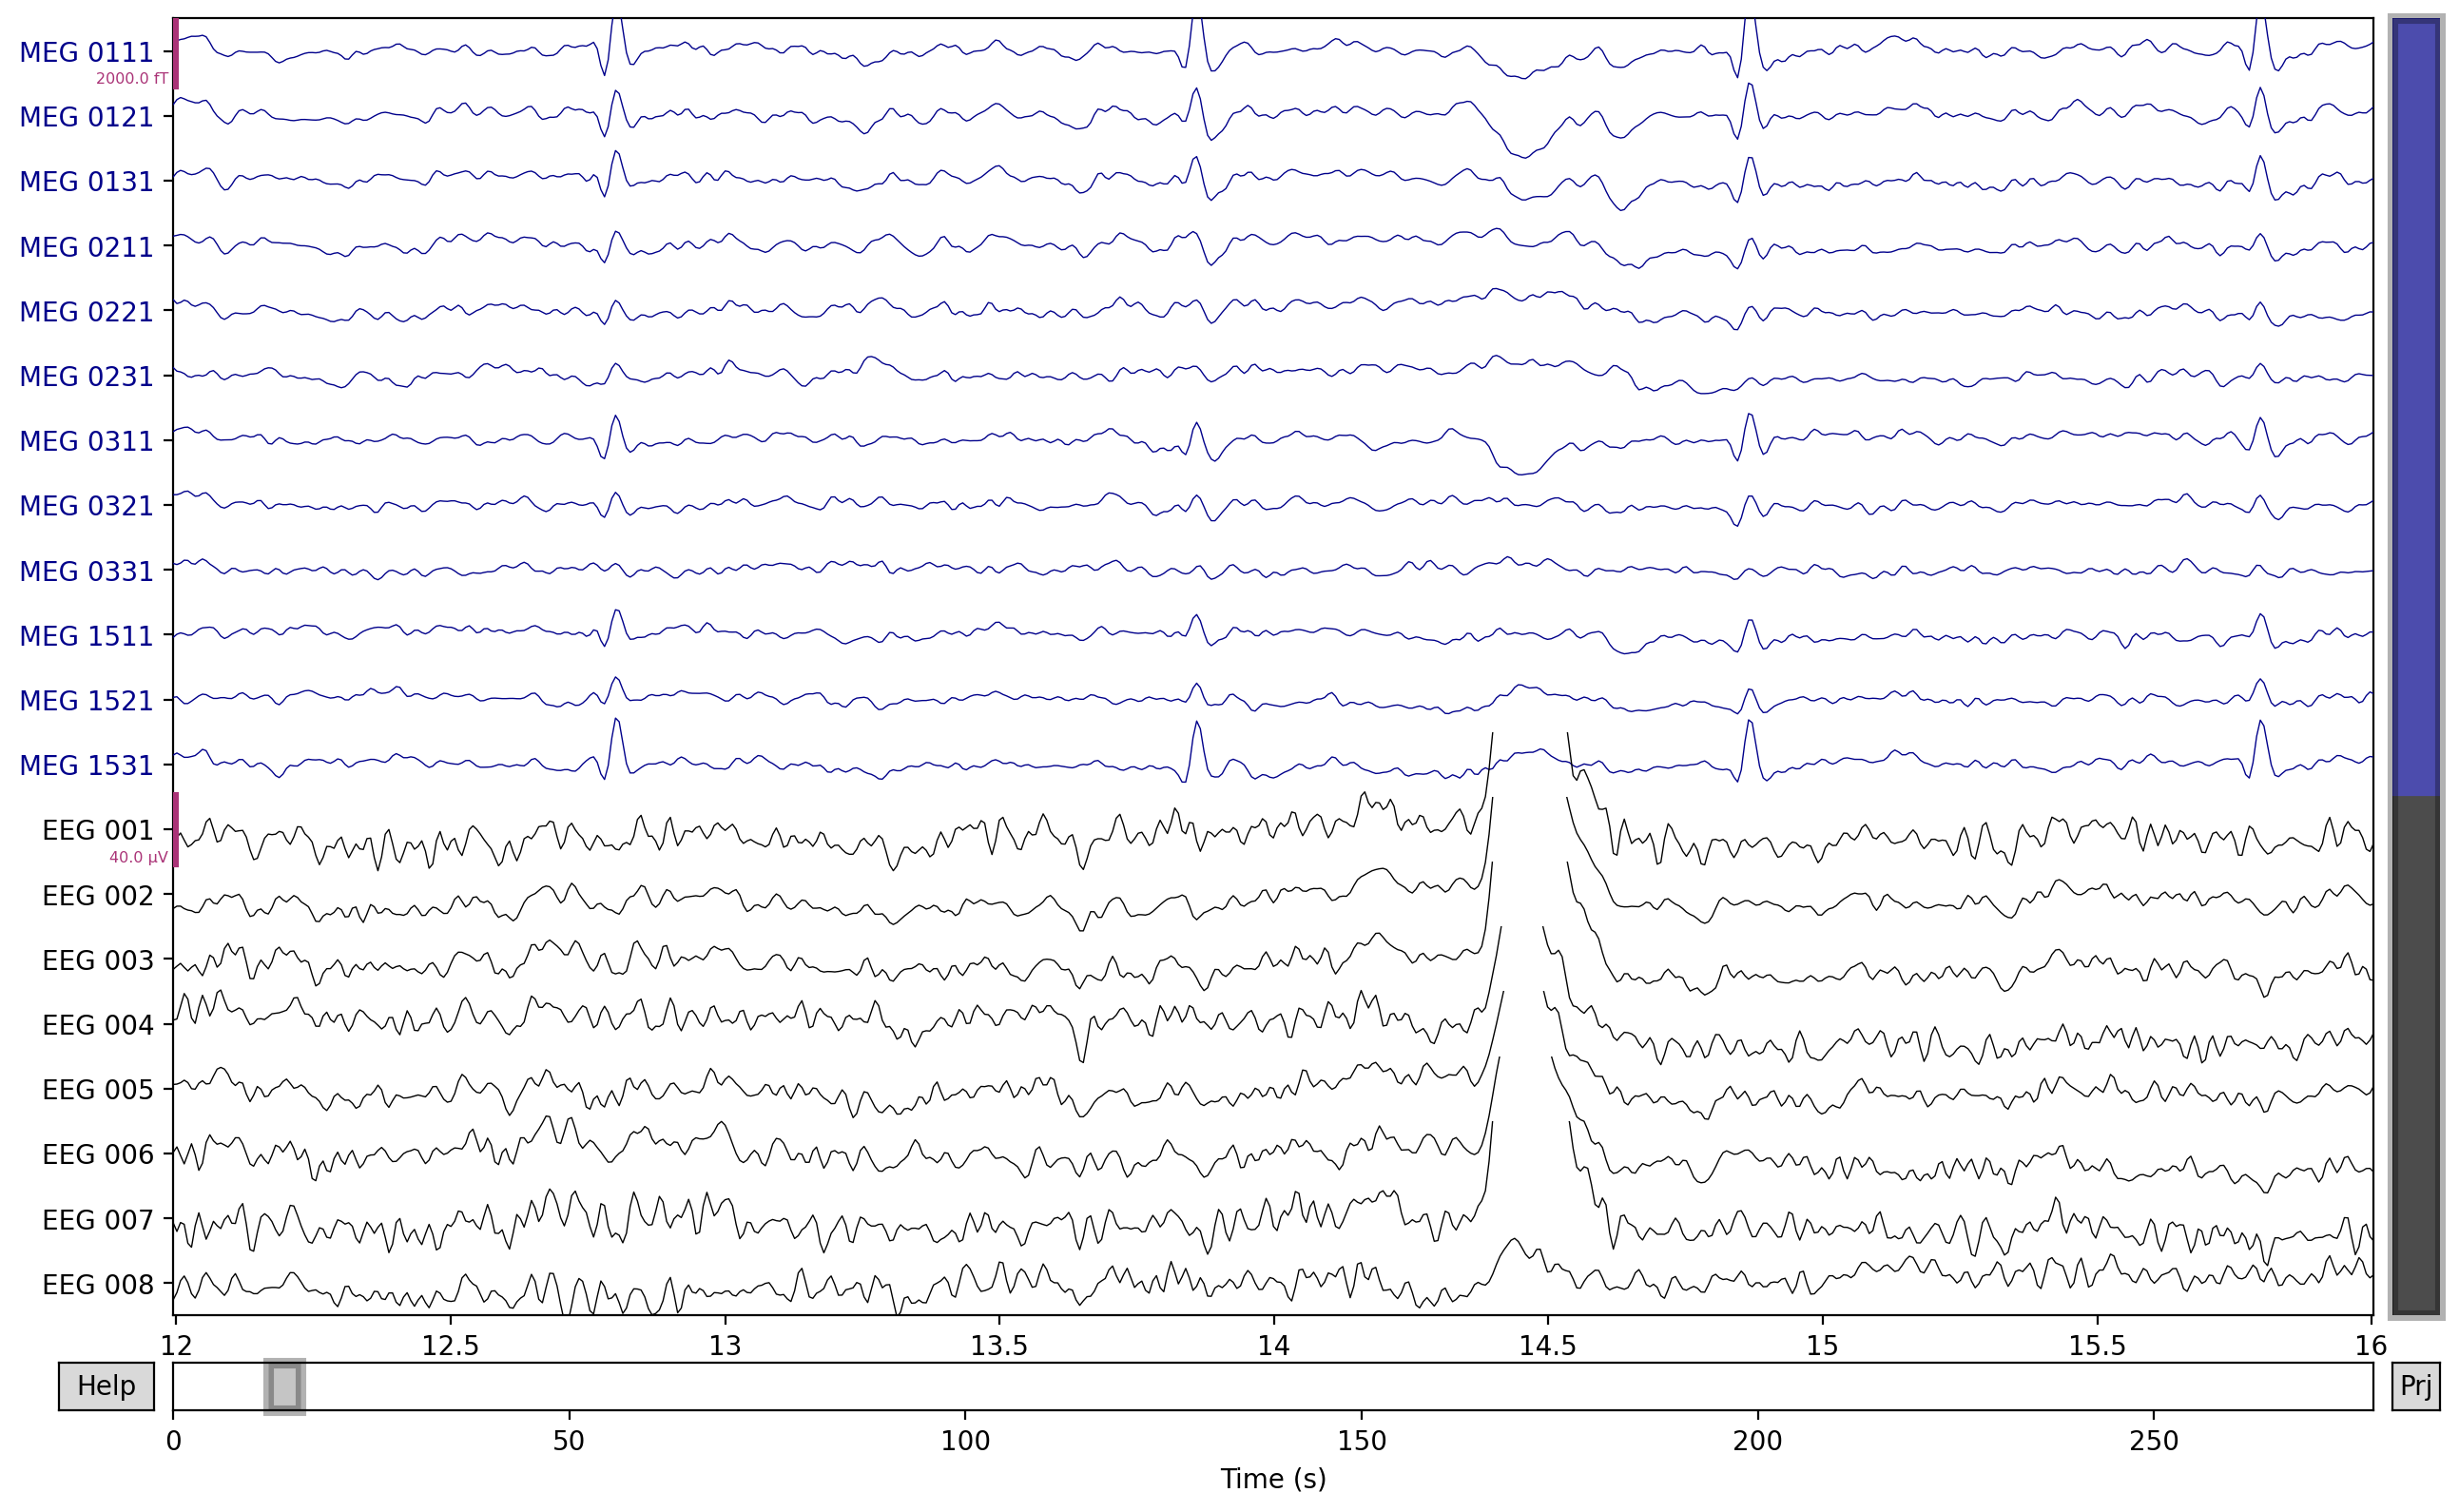

Channels marked as bad:
['EEG 053', np.str_('MEG 2443')]
Channels marked as bad:
['EEG 053', np.str_('MEG 2443')]


In [17]:
%matplotlib qt

orig_raw = raw.copy()
raw.load_data()
ica.apply(raw)

# show some frontal channels to clearly illustrate the artifact removal
chs = [
    "MEG 0111",
    "MEG 0121",
    "MEG 0131",
    "MEG 0211",
    "MEG 0221",
    "MEG 0231",
    "MEG 0311",
    "MEG 0321",
    "MEG 0331",
    "MEG 1511",
    "MEG 1521",
    "MEG 1531",
    "EEG 001",
    "EEG 002",
    "EEG 003",
    "EEG 004",
    "EEG 005",
    "EEG 006",
    "EEG 007",
    "EEG 008",
]
chan_idxs = [raw.ch_names.index(ch) for ch in chs]
orig_raw.plot(order=chan_idxs, start=12, duration=4)
raw.plot(order=chan_idxs, start=12, duration=4)

In [4]:
import pandas as pd

In [1]:
file_path = "adjusted_EXP1_VML_MEG_002loc2_VD_Loads_new.txt"
column_names = ["subID", "sub", "run", "trial", "direction", "ResponseTime", "MovementTime", "ErrorAngle", "AccelerationAngle", "Accuracy", "TimePeakVelocity", "DistancePeakVelocity", "PeakVelocity", "PeakAcceleration", "InitialDirectionAngle", "Outlier", "Keep", "age", "dist_sums", "dist_std", "dist_max", "dist_means", "path_lengths", "angular_averages"]
df = pd.read_csv(file_path, sep="\t", header=None, names=column_names)
print(df.head())

NameError: name 'pd' is not defined

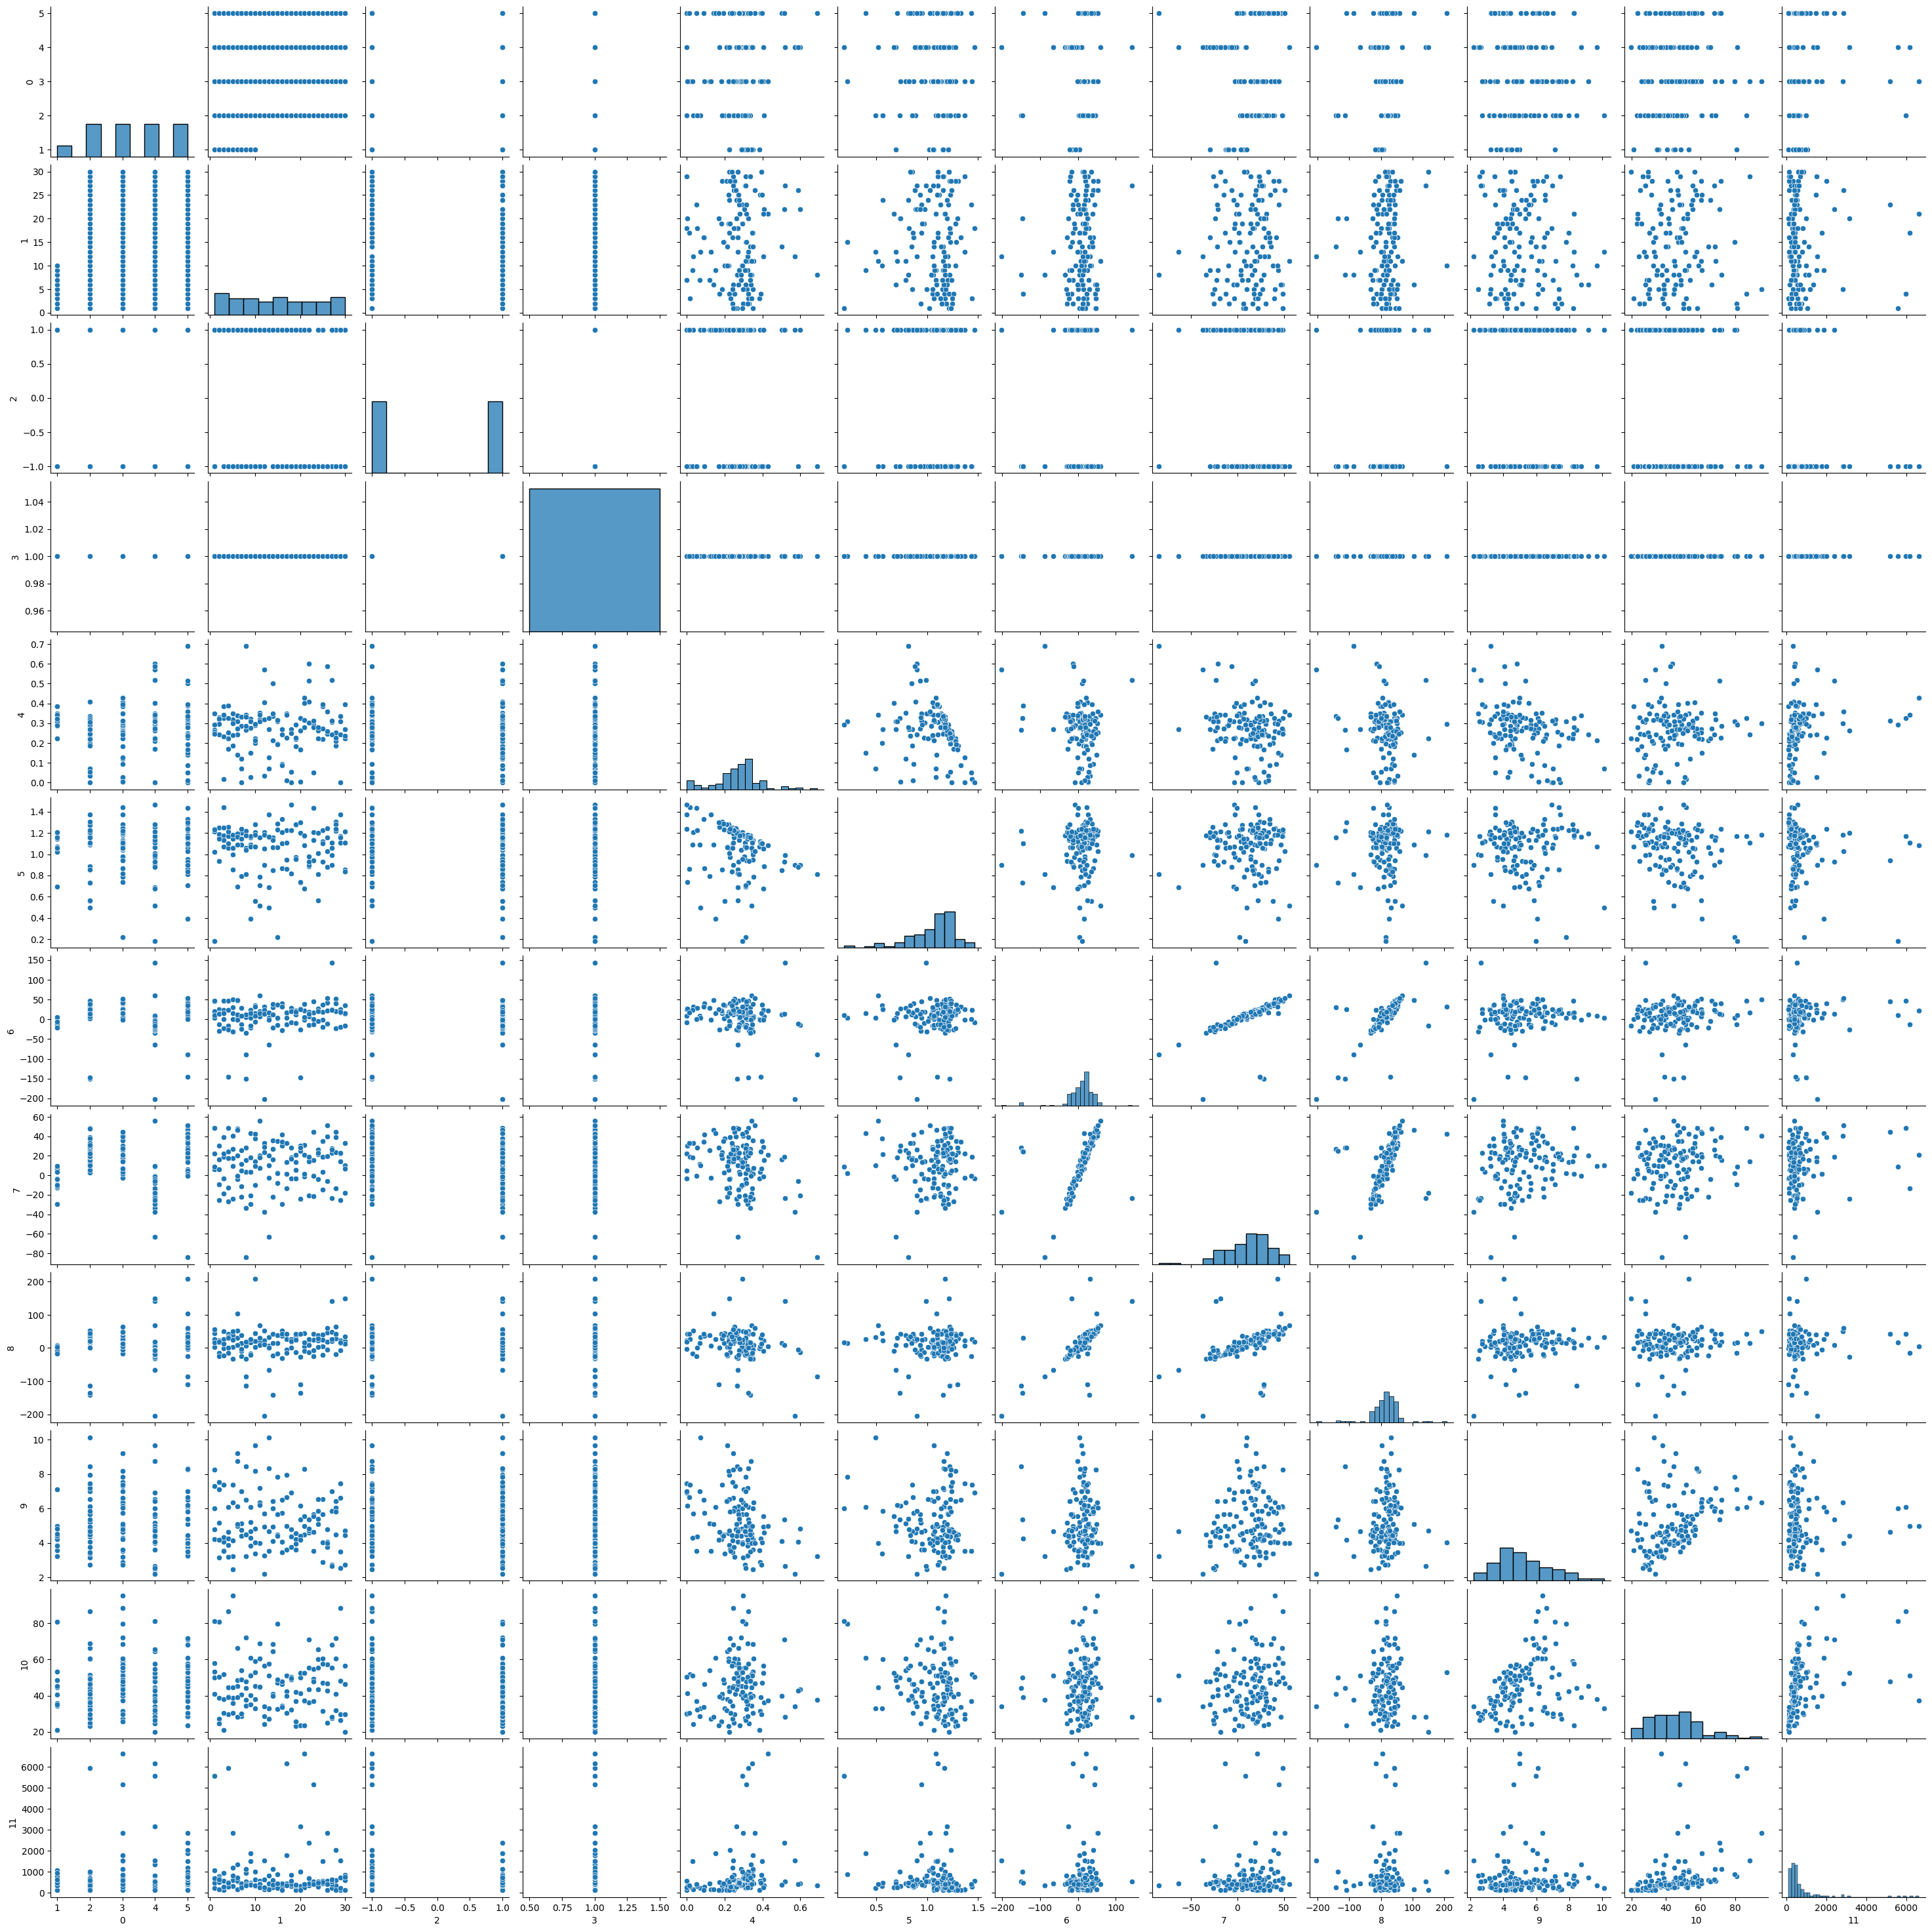

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the pair plot
sns.pairplot(df)
plt.show()

Analyzing columns for a downward trend (negative correlation with trial index):
Column 2: Correlation with trial index = -0.021
Column 5: Correlation with trial index = -0.049
Column 6: Correlation with trial index = -0.004
Column 7: Correlation with trial index = -0.062
Column 9: Correlation with trial index = -0.085

Potential error angle columns (sorted by strength of downward trend):
Column 9 (Correlation: -0.085)
Column 7 (Correlation: -0.062)
Column 5 (Correlation: -0.049)
Column 2 (Correlation: -0.021)
Column 6 (Correlation: -0.004)

To visually confirm the trend for a candidate column (e.g., the one with the strongest negative correlation):


/Users/siddarthchilukuri/Documents/GitHub/IMM-Lab/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/siddarthchilukuri/Documents/GitHub/IMM-Lab/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


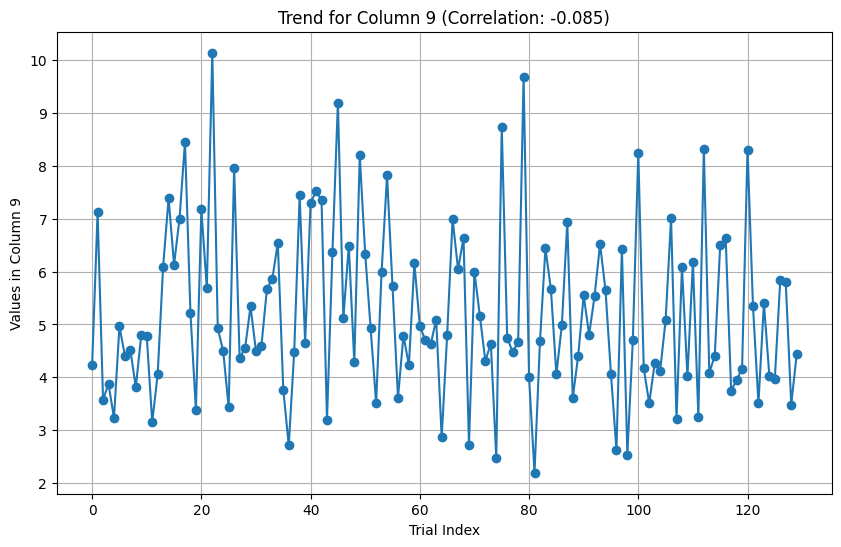

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame from the previous cell
# and that rows represent trials in ascending order.

# Create a 'trial_index' to correlate with
trial_index = np.arange(len(df))
potential_error_angle_columns = []

print("Analyzing columns for a downward trend (negative correlation with trial index):")
for col_idx in df.columns:
    # Ensure the column is numeric before calculating correlation
    if pd.api.types.is_numeric_dtype(df[col_idx]):
        # Calculate Pearson correlation with the trial index
        correlation = df[col_idx].corr(pd.Series(trial_index))
        
        if correlation < 0:
            print(f"Column {col_idx}: Correlation with trial index = {correlation:.3f}")
            potential_error_angle_columns.append((col_idx, correlation))
    else:
        print(f"Column {col_idx}: Skipped (non-numeric data type: {df[col_idx].dtype})")

if not potential_error_angle_columns:
    print("\nNo columns found with a clear downward trend (negative correlation with trial index).")
else:
    # Sort by correlation strength (most negative first)
    potential_error_angle_columns.sort(key=lambda x: x[1])
    print("\nPotential error angle columns (sorted by strength of downward trend):")
    for col, corr in potential_error_angle_columns:
        print(f"Column {col} (Correlation: {corr:.3f})")

    print("\nTo visually confirm the trend for a candidate column (e.g., the one with the strongest negative correlation):")
    if potential_error_angle_columns:
        best_candidate_col = potential_error_angle_columns[0][0]
        
        plt.figure(figsize=(10, 6))
        plt.plot(df.index, df[best_candidate_col], marker='o', linestyle='-')
        plt.xlabel('Trial Index')
        plt.ylabel(f'Values in Column {best_candidate_col}')
        plt.title(f'Trend for Column {best_candidate_col} (Correlation: {potential_error_angle_columns[0][1]:.3f})')
        plt.grid(True)
        plt.show()

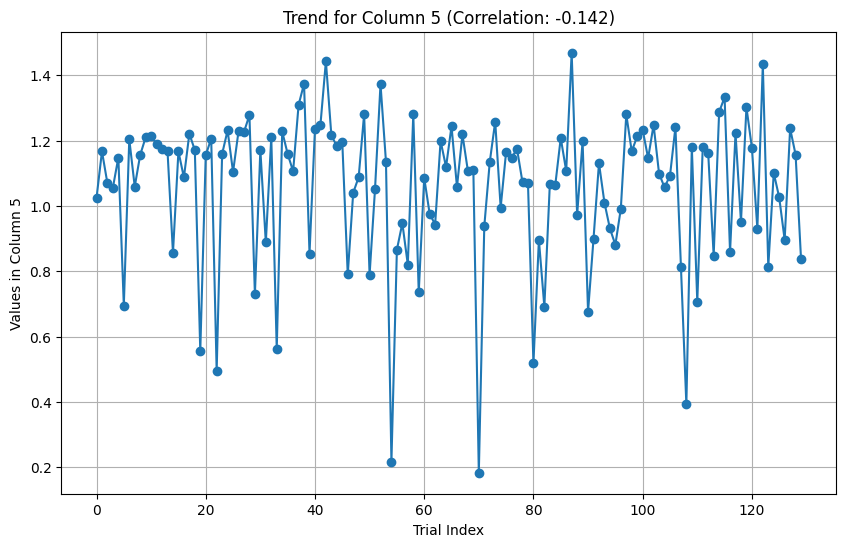

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df[5], marker='o', linestyle='-')
plt.xlabel('Trial Index')
plt.ylabel(f'Values in Column 5')
plt.title(f'Trend for Column 5 (Correlation: -0.142)')
plt.grid(True)
plt.show()

In [15]:
federal_state_file_path = 'fy17_federal-state_summaries 2.csv'
df_federal_state = pd.read_csv(federal_state_file_path)
print(df_federal_state.head())

  Date of Incident                       Employer/Address of Incident   \
0               NaN                                                NaN   
1        04/28/2017  PROWLER RECOVERY, INC., 8100 W. Broward Blvd. ...   
2        04/27/2017  Lydick Hooks Roofing Company, 1741 S. 14th ABI...   
3        04/27/2017  MHP Real Estate Services, 180 Maiden Lane NEW ...   
4        04/27/2017  Randolph & Randolph, LLC, Logging site - near ...   

          Victim(s)                                 Hazard Description   \
0                NaN                                                NaN   
1  Francisco Canjura  A worker died after being caught between two v...   
2     Ismael Mendosa         Worker fatally injured in fall from roof.    
3     Robert Maresca  A worker died after falling from a 6 foot ladder.   
4      John Townsend                  Worker struck and killed by log.    

                            Fatality or Catastrophe   Inspection #   
0  Type2 Fatalities3 Fatalites/1 C